In [1]:
!pip install scikit-learn==1.5.0 pandas==2.2.2 numpy==1.26.4 joblib==1.4.2 matplotlib seaborn -q
print("✅ All dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [2]:
#Import Libraries
import json
import os
import math
import random
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ All imports ready!")

✅ All imports ready!


In [12]:
# ============================================================================
# LOAD DATA FROM GOOGLE DRIVE
# ============================================================================
import os
import json
import shutil
import glob
from google.colab import drive

# 1. Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define the path where you uploaded 'assets' in Google Drive
# If you uploaded 'assets' directly into "My Drive", this is the path:
GDRIVE_DATA_DIR = "/content/drive/MyDrive/assets/ml-service/data"

# Fallback check in case the folder was uploaded with a slightly different structure:
if not os.path.exists(os.path.join(GDRIVE_DATA_DIR, "destinations.json")):
    print("🔍 Searching for destinations.json in your Google Drive...")
    matches = glob.glob("/content/drive/MyDrive/**/destinations.json", recursive=True)
    if matches:
        GDRIVE_DATA_DIR = os.path.dirname(matches[0])
        print(f"📁 Auto-located data directory at: {GDRIVE_DATA_DIR}")
    else:
        raise FileNotFoundError("❌ Could not find destinations.json in your Google Drive. Make sure the 'assets' upload is complete.")

# 3. Create local workspace folders in Colab
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# 4. Copy files from Google Drive to local Colab runtime
shutil.copy(os.path.join(GDRIVE_DATA_DIR, "destinations.json"), "data/destinations.json")

if os.path.exists(os.path.join(GDRIVE_DATA_DIR, "climate.json")):
    shutil.copy(os.path.join(GDRIVE_DATA_DIR, "climate.json"), "data/climate.json")

# 5. Load the JSON data into Python variables
with open("data/destinations.json", "r", encoding="utf-8") as f:
    destinations = json.load(f)

with open("data/climate.json", "r", encoding="utf-8") as f:
    climate = json.load(f)

# 6. Verify that the data loaded properly
print("\n" + "=" * 50)
print("✅ DATA SUCCESSFULLY LOADED FROM GOOGLE DRIVE!")
print("=" * 50)
print(f"  • Destinations loaded : {len(destinations)}")
print(f"  • Climate records     : {len(climate)}")
print(f"  • Sample destination  : {destinations[0]['name']} ({destinations[0]['state']})")
print("=" * 50)


🔗 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ DATA SUCCESSFULLY LOADED FROM GOOGLE DRIVE!
  • Destinations loaded : 50
  • Climate records     : 600
  • Sample destination  : Tarkarli (Maharashtra)


  DATASET SUMMARY
  • Destinations count : 50
  • Unique States      : 14
  • Tiers breakdown    : {'popular': np.int64(31), 'gem': np.int64(12), 'emerging': np.int64(7)}
  • Price range        : ₹1303 – ₹4883
  • Climate records    : 600


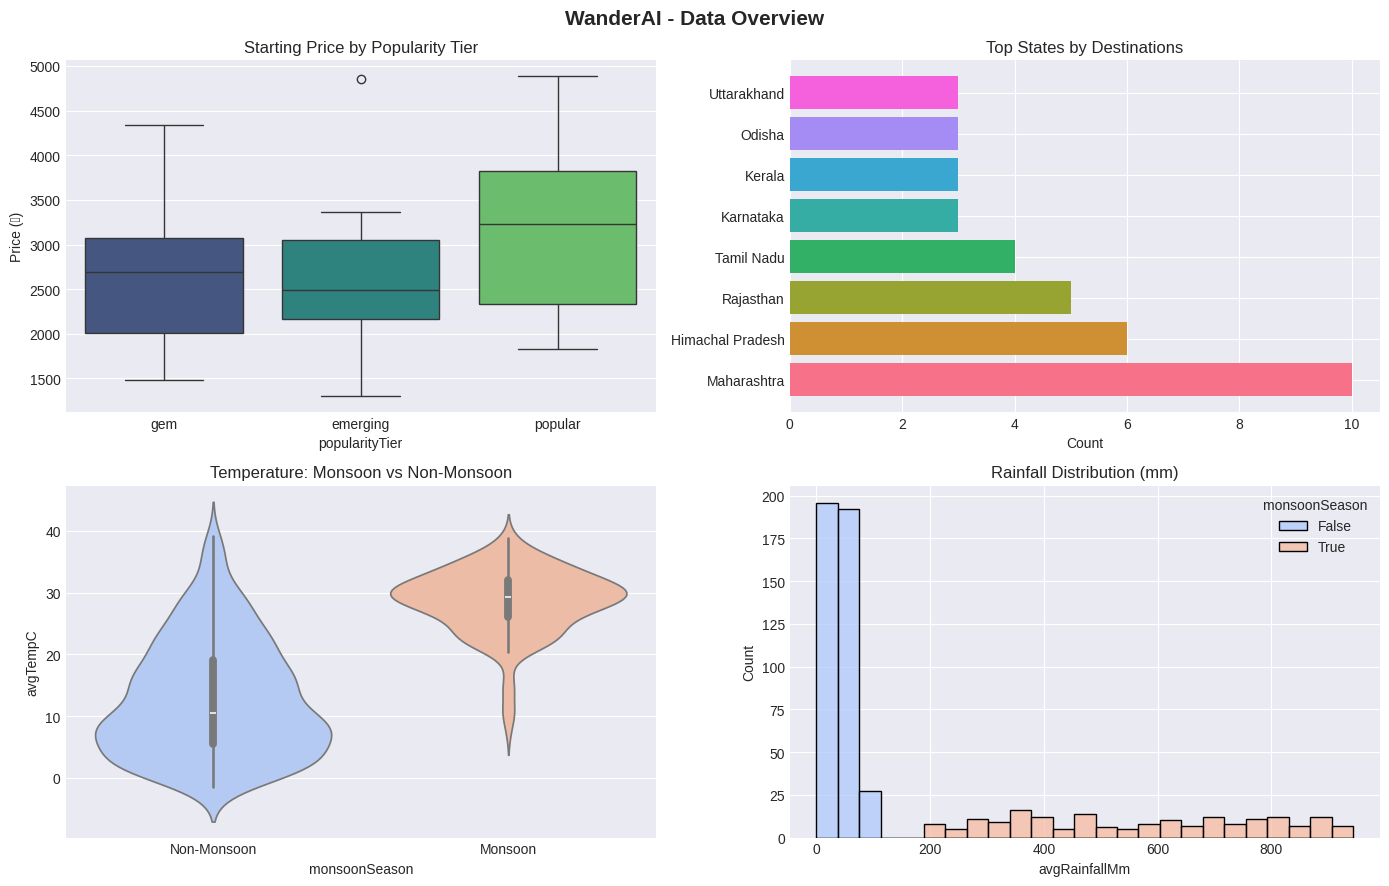

In [13]:
# ============================================================================
# BLOCK 3: Data Exploration
# ============================================================================
df_dest = pd.DataFrame(destinations)
df_climate = pd.DataFrame(climate)

print("=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  • Destinations count : {len(df_dest)}")
print(f"  • Unique States      : {df_dest['state'].nunique()}")
print(f"  • Tiers breakdown    : {dict(df_dest['popularityTier'].value_counts())}")
print(f"  • Price range        : ₹{df_dest['startingPrice'].min()} – ₹{df_dest['startingPrice'].max()}")
print(f"  • Climate records    : {len(df_climate)}")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("WanderAI - Data Overview", fontsize=15, fontweight='bold')

sns.boxplot(data=df_dest, x='popularityTier', y='startingPrice', ax=axes[0, 0],
            order=['gem', 'emerging', 'popular'], palette='viridis')
axes[0, 0].set_title("Starting Price by Popularity Tier")
axes[0, 0].set_ylabel("Price (₹)")

top_states = df_dest['state'].value_counts().head(8)
axes[0, 1].barh(top_states.index, top_states.values, color=sns.color_palette("husl", len(top_states)))
axes[0, 1].set_title("Top States by Destinations")
axes[0, 1].set_xlabel("Count")

sns.violinplot(data=df_climate, x='monsoonSeason', y='avgTempC', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title("Temperature: Monsoon vs Non-Monsoon")
axes[1, 0].set_xticklabels(['Non-Monsoon', 'Monsoon'])

sns.histplot(data=df_climate, x='avgRainfallMm', hue='monsoonSeason', bins=25,
             ax=axes[1, 1], palette='coolwarm', alpha=0.7)
axes[1, 1].set_title("Rainfall Distribution (mm)")

plt.tight_layout()
plt.show()


In [14]:
# ============================================================================
# BLOCK 4: Train Price Prediction Model
# ============================================================================
MONTHS_ORDER = ["January","February","March","April","May","June",
                "July","August","September","October","November","December"]

POPULARITY_SCORE = {"popular": 1.0, "emerging": 0.5, "gem": 0.1}

def demand_multiplier(month_name, best_months, is_holiday, popularity_tier, capacity_load_pct):
    mult = 1.0
    mult += 0.40 if month_name in best_months else 0.0
    mult += 0.25 if is_holiday else 0.0
    mult += 0.15 * POPULARITY_SCORE.get(popularity_tier, 0.5)
    mult += 0.10 * (capacity_load_pct / 100.0)
    return mult

print("🔨 Generating price training features...")
X_price_rows, y_price_rows = [], []
rng = np.random.default_rng(42)

all_tiers = [d.get("popularityTier", "emerging") for d in destinations]
tier_encoder = LabelEncoder()
tier_encoder.fit(all_tiers)

for dest in destinations:
    base_price = dest.get("startingPrice", 3000)
    best_months = dest.get("bestMonths", [])
    pop_tier = dest.get("popularityTier", "emerging")
    cap_load = dest.get("currentCapacityLoadPct", 50)

    for month_idx, month_name in enumerate(MONTHS_ORDER, start=1):
        for hol_flag in [True, False]:
            mult = demand_multiplier(month_name, best_months, hol_flag, pop_tier, float(cap_load))
            noise = rng.normal(1.0, 0.05)
            price = base_price * mult * noise
            tier_enc_val = tier_encoder.transform([pop_tier])[0]
            X_price_rows.append([
                month_idx,
                float(tier_enc_val),
                float(cap_load),
                1.0 if hol_flag else 0.0,
                1.0 if month_name in best_months else 0.0,
            ])
            y_price_rows.append(price)

X_price = np.array(X_price_rows)
y_price = np.array(y_price_rows)
FEATURE_NAMES_PRICE = ["month_num", "popularity_tier_enc", "capacity_load_pct", "is_holiday", "is_best_month"]

# 80/20 Train-Test Split for Validation
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_price, y_price, test_size=0.2, random_state=42)

eval_model_price = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
eval_model_price.fit(X_train_p, y_train_p)
y_pred_price = eval_model_price.predict(X_test_p)

mae_price = mean_absolute_error(y_test_p, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_test_p, y_pred_price))
r2_price = r2_score(y_test_p, y_pred_price)

print("\n" + "=" * 50)
print("  PRICE MODEL EVALUATION (Test Set)")
print("=" * 50)
print(f"  • MAE  : ₹{mae_price:.2f}")
print(f"  • RMSE : ₹{rmse_price:.2f}")
print(f"  • R²   : {r2_price:.4f}")
print("=" * 50)

# Train Final Production Model on 100% Data
final_price_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
final_price_model.fit(X_price, y_price)

joblib.dump(final_price_model, "models/price_model.pkl")
joblib.dump(tier_encoder, "models/tier_encoder.pkl")
print("✅ Saved models/price_model.pkl and models/tier_encoder.pkl")


🔨 Generating price training features...

  PRICE MODEL EVALUATION (Test Set)
  • MAE  : ₹702.39
  • RMSE : ₹965.55
  • R²   : 0.6708
✅ Saved models/price_model.pkl and models/tier_encoder.pkl


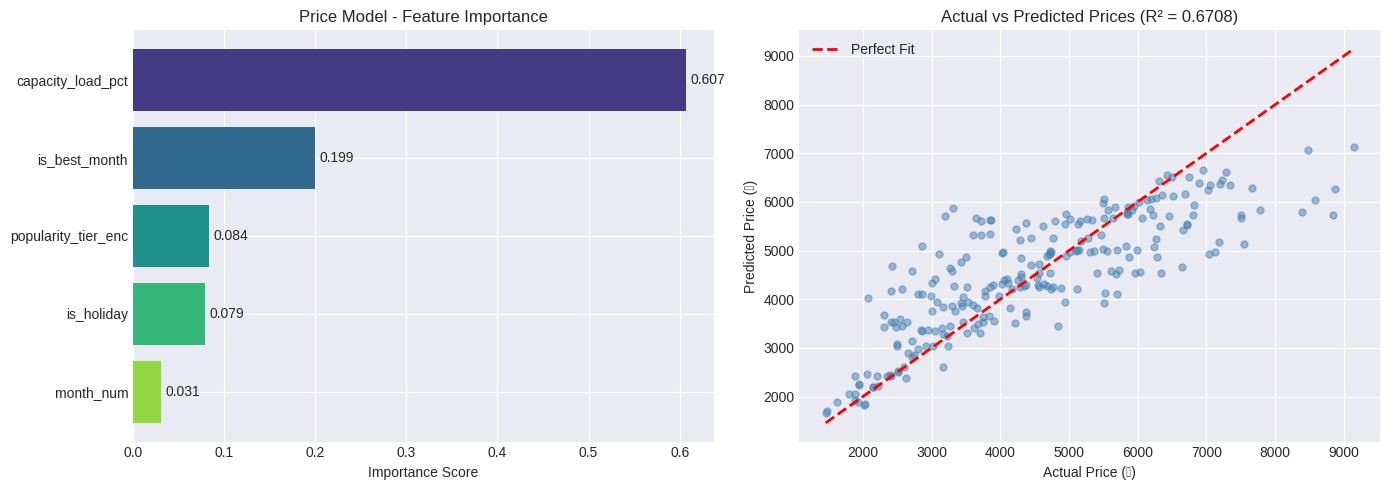

In [15]:
# ============================================================================
# BLOCK 5: Price Model Plots
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Feature Importance
importances_p = dict(zip(FEATURE_NAMES_PRICE, final_price_model.feature_importances_))
sorted_p = sorted(importances_p.items(), key=lambda x: x[1], reverse=True)
names_p, vals_p = zip(*sorted_p)
axes[0].barh(names_p[::-1], vals_p[::-1], color=sns.color_palette("viridis", len(names_p))[::-1])
axes[0].set_title("Price Model - Feature Importance")
axes[0].set_xlabel("Importance Score")
for i, v in enumerate(vals_p[::-1]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center')

# 2. Actual vs Predicted
axes[1].scatter(y_test_p, y_pred_price, alpha=0.5, s=25, c='steelblue')
min_val = min(y_test_p.min(), y_pred_price.min())
max_val = max(y_test_p.max(), y_pred_price.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[1].set_title(f"Actual vs Predicted Prices (R² = {r2_price:.4f})")
axes[1].set_xlabel("Actual Price (₹)")
axes[1].set_ylabel("Predicted Price (₹)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
# ============================================================================
# BLOCK 6: Train Weather-Fit Model
# ============================================================================
def weather_fit_label(row, activity_type):
    rain = row.get("avgRainfallMm", 0)
    temp = row.get("avgTempC", 25)
    hum = row.get("avgHumidityPct", 60)

    rain_penalty = min(100.0, rain / 10.0) if activity_type == "outdoor" else min(40.0, rain / 25.0)
    temp_penalty = max(0.0, (abs(temp - 25.0) - 3.0) * 2.0)
    hum_penalty = max(0.0, (hum - 70.0) / 3.0)

    score = max(0.0, 100.0 - rain_penalty - temp_penalty - hum_penalty)
    return round(score, 2)

print("🔨 Generating weather-fit features...")
X_weather_rows, y_weather_rows = [], []

for row in climate:
    for activity_type_int, activity_type_str in [(0, "indoor"), (1, "outdoor")]:
        label = weather_fit_label(row, activity_type_str)
        X_weather_rows.append([
            row.get("avgTempC", 25),
            row.get("avgRainfallMm", 0),
            row.get("avgHumidityPct", 60),
            1 if row.get("monsoonSeason") else 0,
            activity_type_int,
        ])
        y_weather_rows.append(label)

X_weather = np.array(X_weather_rows)
y_weather = np.array(y_weather_rows)
FEATURE_NAMES_WEATHER = ["avgTempC", "avgRainfallMm", "avgHumidityPct", "monsoonSeason", "activityType"]

# 80/20 Split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weather, y_weather, test_size=0.2, random_state=42)

eval_model_weather = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
eval_model_weather.fit(X_train_w, y_train_w)
y_pred_weather = eval_model_weather.predict(X_test_w)

mae_weather = mean_absolute_error(y_test_w, y_pred_weather)
rmse_weather = np.sqrt(mean_squared_error(y_test_w, y_pred_weather))
r2_weather = r2_score(y_test_w, y_pred_weather)

print("\n" + "=" * 50)
print("  WEATHER-FIT MODEL EVALUATION (Test Set)")
print("=" * 50)
print(f"  • MAE  : {mae_weather:.2f} points")
print(f"  • RMSE : {rmse_weather:.2f} points")
print(f"  • R²   : {r2_weather:.4f}")
print("=" * 50)

# Final Production Model
final_weather_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
final_weather_model.fit(X_weather, y_weather)

joblib.dump(final_weather_model, "models/weather_fit_model.pkl")
print("✅ Saved models/weather_fit_model.pkl")


🔨 Generating weather-fit features...

  WEATHER-FIT MODEL EVALUATION (Test Set)
  • MAE  : 1.04 points
  • RMSE : 2.25 points
  • R²   : 0.9868
✅ Saved models/weather_fit_model.pkl


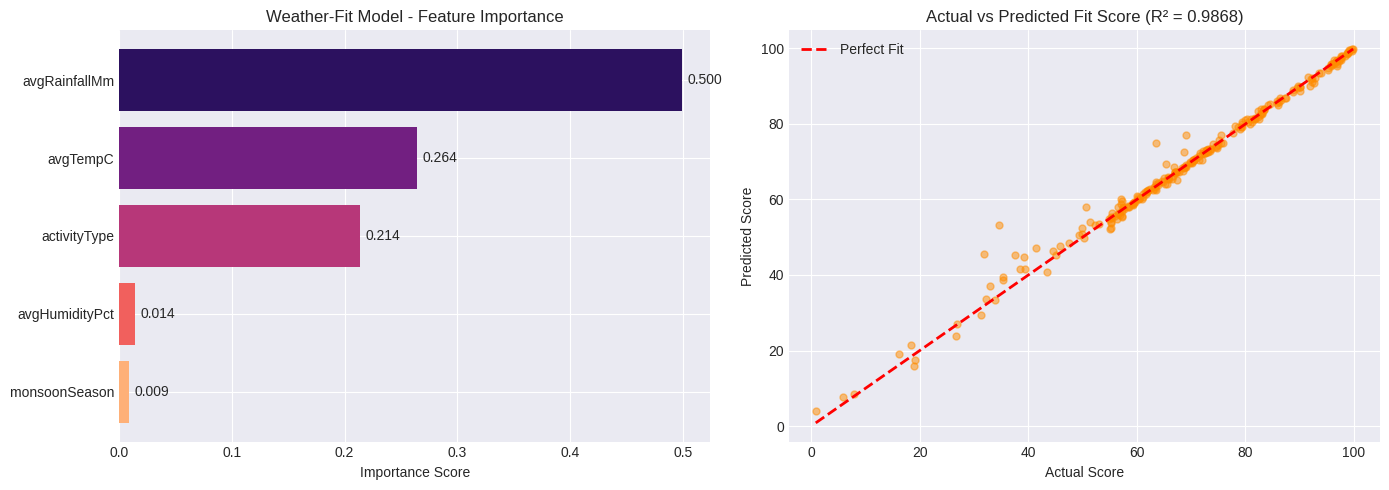

In [17]:
# ============================================================================
# BLOCK 7: Weather Model Plots
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Feature Importance
importances_w = dict(zip(FEATURE_NAMES_WEATHER, final_weather_model.feature_importances_))
sorted_w = sorted(importances_w.items(), key=lambda x: x[1], reverse=True)
names_w, vals_w = zip(*sorted_w)
axes[0].barh(names_w[::-1], vals_w[::-1], color=sns.color_palette("magma", len(names_w))[::-1])
axes[0].set_title("Weather-Fit Model - Feature Importance")
axes[0].set_xlabel("Importance Score")
for i, v in enumerate(vals_w[::-1]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center')

# 2. Actual vs Predicted
axes[1].scatter(y_test_w, y_pred_weather, alpha=0.5, s=25, c='darkorange')
min_w = min(y_test_w.min(), y_pred_weather.min())
max_w = max(y_test_w.max(), y_pred_weather.max())
axes[1].plot([min_w, max_w], [min_w, max_w], 'r--', lw=2, label='Perfect Fit')
axes[1].set_title(f"Actual vs Predicted Fit Score (R² = {r2_weather:.4f})")
axes[1].set_xlabel("Actual Score")
axes[1].set_ylabel("Predicted Score")
axes[1].legend()

plt.tight_layout()
plt.show()


In [18]:
# ============================================================================
# BLOCK 8: Save & Export Models to Google Drive
# ============================================================================
# 1. Save directly into your Google Drive's ml-service/models folder
gdrive_models_dir = os.path.join(os.path.dirname(GDRIVE_DATA_DIR), "models")
os.makedirs(gdrive_models_dir, exist_ok=True)

shutil.copy("models/price_model.pkl", os.path.join(gdrive_models_dir, "price_model.pkl"))
shutil.copy("models/tier_encoder.pkl", os.path.join(gdrive_models_dir, "tier_encoder.pkl"))
shutil.copy("models/weather_fit_model.pkl", os.path.join(gdrive_models_dir, "weather_fit_model.pkl"))

print("=" * 60)
print("💾 MODELS SAVED DIRECTLY TO GOOGLE DRIVE!")
print("=" * 60)
print(f"  • Target Directory: {gdrive_models_dir}")
print("  • Saved Files:")
print("      - price_model.pkl")
print("      - tier_encoder.pkl")
print("      - weather_fit_model.pkl")
print("=" * 60)

# 2. Also trigger a browser download for backup
from google.colab import files
print("\n📥 Initiating backup downloads to your computer...")
files.download('models/price_model.pkl')
files.download('models/tier_encoder.pkl')
files.download('models/weather_fit_model.pkl')


💾 MODELS SAVED DIRECTLY TO GOOGLE DRIVE!
  • Target Directory: /content/drive/MyDrive/assets/ml-service/models
  • Saved Files:
      - price_model.pkl
      - tier_encoder.pkl
      - weather_fit_model.pkl

📥 Initiating backup downloads to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# ============================================================================
# BLOCK 9: Test Predictions
# ============================================================================
print("=" * 55)
print("  PREDICTION TEST ON TRAINED MODELS")
print("=" * 55)

# 1. Price prediction test for Goa
goa_data = next((d for d in destinations if d.get('name') == 'Goa'), destinations[0])
goa_tier = float(tier_encoder.transform([goa_data['popularityTier']])[0])
cap = float(goa_data.get('currentCapacityLoadPct', 50))

print(f"\n🏷️ Price Predictions for {goa_data['name']} (Base: ₹{goa_data['startingPrice']}):")
for m_idx, m_name in enumerate(["May", "August", "December"], 1):
    month_num = MONTHS_ORDER.index(m_name) + 1
    is_best = 1.0 if m_name in goa_data.get('bestMonths', []) else 0.0
    for hol in [0.0, 1.0]:
        feat = np.array([[month_num, goa_tier, cap, hol, is_best]])
        pred = final_price_model.predict(feat)[0]
        tag = "Holiday" if hol else "Regular"
        print(f"  • {m_name:<10} ({tag:>7}) : ₹{pred:,.0f}")

# 2. Weather Fit score test
print(f"\n🌦️ Weather-Fit Score for Tarkarli (dest-001):")
tarkarli_climate = [c for c in climate if c.get('destinationId') == 'dest-001'][:4]
for r in tarkarli_climate:
    feat = np.array([[r['avgTempC'], r['avgRainfallMm'], r['avgHumidityPct'], 1 if r.get('monsoonSeason') else 0, 1]])
    score = final_weather_model.predict(feat)[0]
    score = max(0, min(100, score))
    label = "Excellent" if score >= 80 else "Good" if score >= 60 else "Fair" if score >= 40 else "Poor"
    print(f"  • {r['month']:<10} : {score:5.1f} ({label})")

print("\n✅ All models trained, verified, and exported!")


  PREDICTION TEST ON TRAINED MODELS

🏷️ Price Predictions for Goa (Base: ₹4883):
  • May        (Regular) : ₹4,675
  • May        (Holiday) : ₹6,042
  • August     (Regular) : ₹4,725
  • August     (Holiday) : ₹5,952
  • December   (Regular) : ₹5,405
  • December   (Holiday) : ₹6,438

🌦️ Weather-Fit Score for Tarkarli (dest-001):
  • January    :  61.0 (Good)
  • February   :  63.7 (Good)
  • March      :  75.6 (Good)
  • April      :  87.5 (Excellent)

✅ All models trained, verified, and exported!
